# EDA da Carta de Serviços ao Cidadão 2026

## Pergunta central
Este documento está pronto para servir de base de conhecimento do chatbot do SUS? O que ele cobre, com que qualidade e estrutura, e como preparar o conteúdo para a LLM?

**Objetivo.** Diagnosticar cobertura, qualidade da extração, estrutura, informação prática, vocabulário e redundância da cartilha da SES-DF, convertendo os achados em decisões de engenharia para RAG. Esta é uma análise descritiva de um único documento, não uma inferência estatística.

**Perguntas de apoio.** Quais serviços aparecem? A divisão em seções é confiável? Onde estão telefones, horários, endereços e links? Quais siglas o chatbot precisa conhecer? Quais trechos podem confundir a recuperação?

**Níveis.** Básico = inspeção e limpeza; Intermediário = características, distribuições e relações; Avançado = TF-IDF, similaridade, agrupamento, tópicos, cobertura e prontidão para RAG.

## Índice
1. [Configuração](#1-configuração) · 2. [Dados](#2-entendimento-dos-dados) · 3. [Inspeção](#3-carga-e-inspeção-inicial) · 4. [Limpeza](#4-limpeza) · 5. [Qualidade](#5-qualidade) · 6. [Características](#6-engenharia-de-características) · 7. [Univariada](#7-análise-univariada) · 8. [Bivariada](#8-análise-bivariada) · 9. [Multivariada](#9-análise-multivariada) · 10. [Outliers](#10-outliers) · 11. [Cobertura](#11-cobertura) · 12. [RAG](#12-prontidão-para-rag) · 13. [Conclusões](#13-conclusões)

## Glossário
EDA: análise exploratória de dados. Corpus: conjunto de textos analisados. Seção: unidade delimitada na extração. Token: unidade aproximada consumida pela LLM. Stopword: palavra funcional removida para observar termos informativos. TF-IDF: peso que destaca termos importantes em um documento e raros no corpus. Chunking: divisão do texto em blocos para recuperação. RAG: geração aumentada por recuperação de fontes. Outlier: observação muito diferente das demais. IQR: intervalo entre quartis, usado para sinalizar extremos. Similaridade do cosseno: medida de proximidade entre vetores de texto.

## Premissas adotadas
O arquivo PDF encontrado chama-se `cartasus.pdf`, embora o enunciado use `cartilha.pdf`. O notebook procura ambos. A segmentação alternativa agrupa linhas do CSV até o próximo título de serviço do sumário; a linha inicial de capa/sumário continua registrada. Telefones, links e endereços são detectados por regex e exigem validação humana. A estimativa de tokens usa 1,4 token por palavra em português; ela orienta chunking, não substitui o tokenizador da LLM.

# 1. Configuração
Nesta etapa importamos as bibliotecas, criamos as pastas de saída e definimos caminhos relativos. Assim o notebook pode ser movido entre máquinas sem espalhar caminhos absolutos pelo código. Stopwords são mantidas no próprio notebook para evitar downloads de rede.

In [1]:
from pathlib import Path
import re, unicodedata, json, sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import spearmanr, mannwhitneyu
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

BASE = Path.cwd()
if not (BASE / 'cartilha_secoes.csv').exists() and (BASE.parent / 'cartilha_secoes.csv').exists(): BASE = BASE.parent
RAW = BASE / 'data' / 'raw'
PROC = BASE / 'data' / 'processed'
FIG = BASE / 'reports' / 'figures'
RAW.mkdir(parents=True, exist_ok=True); PROC.mkdir(parents=True, exist_ok=True); FIG.mkdir(parents=True, exist_ok=True)
candidatos = [RAW/'cartilha_secoes.csv', BASE/'cartilha_secoes.csv']
CSV_PATH = next((p for p in candidatos if p.exists()), None)
if CSV_PATH is None: raise FileNotFoundError('Não encontrei cartilha_secoes.csv em data/raw/ ou na raiz.')
PDF_PATH = next((p for p in [RAW/'cartilha.pdf', RAW/'cartasus.pdf', BASE/'cartilha.pdf', BASE/'cartasus.pdf'] if p.exists()), None)
STOPWORDS = set('a ao aos aquela aquelas aquele aqueles aquilo as até com como da das de dela delas dele deles depois do dos e é em entre era essa essas esse esses esta está estas este estes eu foi for há isso isto já la lhe mais mas me meu minha minhas meu não nas no nos nossa nossas nosso nossos o os ou para pela pelas pelo pelos por qual quando que quem se sem ser seu seus sob sobre sua suas também te tem tendo ter um uma umas uns vai você vocês'.split())
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'axes.titlesize': 13})
print(f'Python: {sys.version.split()[0]} | plataforma: {platform.platform()}')
print(f'CSV: {CSV_PATH} | PDF encontrado: {PDF_PATH}')
print('Saídas:', PROC, FIG)

Python: 3.14.6 | plataforma: macOS-26.6-arm64-arm-64bit-Mach-O
CSV: /Users/aluno2/Documents/EDAcartilha/cartilha_secoes.csv | PDF encontrado: /Users/aluno2/Documents/EDAcartilha/cartasus.pdf
Saídas: /Users/aluno2/Documents/EDAcartilha/data/processed /Users/aluno2/Documents/EDAcartilha/reports/figures


# 2. Entendimento dos dados
O CSV é a tabela principal da extração. Primeiro documentamos o significado das colunas e as limitações conhecidas, antes de transformar qualquer texto.

In [2]:
dicionario = pd.DataFrame([
 {'variavel':'titulo','significado':'Título reconhecido pelo conversor PDF/Markdown','tipo':'texto/categórico','observacao':'Pode conter Markdown, HTML ou subtítulos genéricos'},
 {'variavel':'pagina','significado':'Página inicial da seção','tipo':'numérico','observacao':'Não é necessariamente a página de todo o conteúdo'},
 {'variavel':'texto','significado':'Texto entre este título e o próximo','tipo':'texto','observacao':'Pode conter NaN, vazios, colunas desordenadas e resíduos de imagem'},
 {'variavel':'n_palavras','significado':'Contagem produzida na extração','tipo':'numérico','observacao':'Será recalculada após a limpeza'}])
display(dicionario)
print('Limitações: documento único; amostra pequena; possível perda de tabelas/colunas; títulos dependentes de #; informação de imagem pode aparecer fora de ordem.')

,variavel,significado,tipo,observacao
0,titulo,Título reconhecido pelo conversor PDF/Markdown,texto/categórico,"Pode conter Markdown, HTML ou subtítulos genér..."
1,pagina,Página inicial da seção,numérico,Não é necessariamente a página de todo o conteúdo
2,texto,Texto entre este título e o próximo,texto,"Pode conter NaN, vazios, colunas desordenadas ..."
3,n_palavras,Contagem produzida na extração,numérico,Será recalculada após a limpeza


Limitações: documento único; amostra pequena; possível perda de tabelas/colunas; títulos dependentes de #; informação de imagem pode aparecer fora de ordem.


# 3. Carga e inspeção inicial [BÁSICO]
Lemos com `pandas`, que preserva corretamente quebras de linha dentro das células. Texto vazio convertido em `NaN` será tratado como string vazia em uma cópia de trabalho.

In [3]:
df_raw = pd.read_csv(CSV_PATH)
df = df_raw.copy()
df['titulo'] = df['titulo'].fillna('')
df['texto'] = df['texto'].fillna('')
print('shape:', df.shape)
display(df.head(3))
display(df.dtypes.to_frame('tipo'))
display(df.isna().sum().to_frame('faltantes'))
print('páginas em ordem crescente:', df['pagina'].is_monotonic_increasing)
print('títulos repetidos:', int(df['titulo'].duplicated(keep=False).sum()))
print('textos duplicados:', int(df['texto'].duplicated(keep=False).sum()))
display(df.nsmallest(10,'n_palavras')[['titulo','pagina','n_palavras']])
display(df.nlargest(10,'n_palavras')[['titulo','pagina','n_palavras']])

shape: (124, 4)


,titulo,pagina,texto,n_palavras
0,**Secretaria de Saúde do Distrito Federal**,1,Carta de Serviços Ao Cidadão **2026** \n\n\n\n...,80
1,**DESCRIÇÃO**,4,É um espaço destinado para você! Utilize o seu...,36
2,**SERVIÇOS**,4,Lei de Acesso à Informação ( LAI). Registros d...,19


,tipo
titulo,str
pagina,int64
texto,str
n_palavras,int64


,faltantes
titulo,0
pagina,0
texto,0
n_palavras,0


páginas em ordem crescente: True
títulos repetidos: 102
textos duplicados: 41


,titulo,pagina,n_palavras
3,**OUVIDORIA**,4,0
7,**LEI DE ACESSO À INFORMAÇÃO – LAI**,5,0
10,**PRAZO DE RESPOSTA**,5,0
12,**QR CODE**,5,0
13,**LEI DE ACESSO À INFORMAÇÃO – LAI**,6,0
14,**DESCRIÇÃO**,6,0
21,**QR CODE**,7,0
22,**E-PROTOCOLO**,8,0
25,**PROTOCOLO DA SES/DF**,9,0
30,**QR CODE**,9,0


,titulo,pagina,n_palavras
76,**QR CODE**,21,127
40,**SERVIÇOS**,12,124
24,**COMO ACOMPANHAR**,8,113
15,**ETAPAS**,6,111
23,**ETAPAS**,8,108
59,**SERVIÇOS**,17,100
54,**MAIS SERVIÇOS DOS CENTROS DE REFERÊNCIA AQUI!**,15,94
0,**Secretaria de Saúde do Distrito Federal**,1,80
18,**DESCRIÇÃO**,7,75
9,**ACESSO**,5,74


## Interpretação
A inspeção mostra a qualidade da segmentação original sem apagar evidências. Muitos títulos repetidos, blocos vazios e títulos como `QR CODE` indicam que a divisão por todo `#` não representa necessariamente serviços. A versão original será mantida para rastreabilidade.

## Ponto de controle de segmentação
Para verificar uma alternativa, usamos os serviços do sumário como âncoras. Cada linha original é atribuída ao último serviço reconhecido. Isso produz blocos semânticos maiores, adequados à recuperação, e permite comparar contagem e tamanho com a divisão mecânica.

In [4]:
servicos = ['Ouvidoria','Lei de Acesso à Informação (LAI)','e-Protocolo','Atendimento em Unidade Básica de Saúde (UBS)','Atendimento em Policlínicas','Centros Especializados','Saúde Mental (CAPS)','Protocolo da SES/DF','Sistema de Peticionamento Eletrônico (SISPE)','SAMU-DF 192','Atendimento em Unidades de Pronto Atendimento (UPAs)','Atendimento em Hospitais','Farmácias e Medicamentos','Banco de Leite Humano','Atenção Domiciliar','Cuidados Paliativos','Doação e Transplante de Órgãos','Terapia Renal Substitutiva','Vigilância em Saúde','Órtese e Prótese','Atendimento em Libras']
def norm(s): return ''.join(c for c in unicodedata.normalize('NFD', str(s).lower()) if unicodedata.category(c) != 'Mn')
def ancora(t):
    n = norm(t)
    for s in servicos:
        palavras = [norm(x) for x in re.findall(r'[a-z0-9]+', s) if len(x)>2]
        if len(palavras) >= 2 and sum(p in n for p in palavras) >= min(2,len(palavras)):
            return s
    return None

corrente = 'Capa e sumário'
registros = []
for _, row in df.iterrows():
    achou = ancora(row['titulo'])
    if achou: corrente = achou
    registros.append({'servico':corrente, 'titulo_origem':row['titulo'], 'pagina':row['pagina'], 'texto':row['texto']})
alt = pd.DataFrame(registros)
alt = alt.groupby('servico', sort=False).agg(pagina=('pagina','min'), titulo=('servico','first'), texto=('texto', lambda x: '\n\n'.join(v for v in x if v))).reset_index(drop=True)
alt['n_palavras'] = alt['texto'].str.split().str.len()
display(alt[['titulo','pagina','n_palavras']])
print(f'Seções originais: {len(df)} | blocos alternativos: {len(alt)} | vazios alternativos: {(alt.n_palavras==0).sum()}')

,titulo,pagina,n_palavras
0,Capa e sumário,1,176
1,Lei de Acesso à Informação (LAI),5,366
2,Atendimento em Unidades de Pronto Atendimento ...,7,686
3,Sistema de Peticionamento Eletrônico (SISPE),10,67
4,Atendimento em Unidade Básica de Saúde (UBS),11,295
5,Atendimento em Policlínicas,13,121
6,Centros Especializados,14,435
7,Farmácias e Medicamentos,24,176
8,Banco de Leite Humano,26,71
9,Atenção Domiciliar,27,76


Seções originais: 124 | blocos alternativos: 14 | vazios alternativos: 0


## Interpretação e decisão
A segmentação por serviço é a unidade recomendada para RAG, mas não substitui uma revisão editorial: a extração de tabelas e imagens pode ter misturado conteúdo. A tabela original será usada para auditoria e a alternativa será usada na exportação limpa, com a origem preservada nos metadados.

# 4. Limpeza com rastreabilidade [BÁSICO]
A limpeza remove apenas marcas de apresentação e espaços artificiais. Números, acentos, siglas, telefones e links são preservados. As colunas brutas continuam disponíveis para comparação.

In [5]:
def limpar_texto(valor):
    texto = '' if pd.isna(valor) else str(valor)
    texto = re.sub(r'<!--.*?-->', ' ', texto, flags=re.S)
    texto = re.sub(r'<[^>]+>', ' ', texto)
    texto = texto.replace('**','').replace('__','').replace('\u00a0',' ')
    texto = re.sub(r'(?<=\w)-\s*\n\s*(?=\w)', '', texto)
    texto = re.sub(r'[ \t]+', ' ', texto)
    texto = re.sub(r'\n{3,}', '\n\n', texto)
    return texto.strip()

limpo = df.copy()
limpo['titulo_bruto'] = limpo['titulo']; limpo['texto_bruto'] = limpo['texto']
limpo['titulo'] = limpo['titulo'].map(limpar_texto); limpo['texto'] = limpo['texto'].map(limpar_texto)
limpo['tipo'] = np.where((limpo.index==0) | (limpo['pagina']==1), 'capa_sumario', 'conteudo')
limpo['alterado'] = (limpo['titulo'] != limpo['titulo_bruto']) | (limpo['texto'] != limpo['texto_bruto'])
limpo['n_palavras'] = limpo['texto'].str.findall(r'\b\w+\b').str.len()
print('seções alteradas:', int(limpo['alterado'].sum()))
display(limpo.loc[limpo['alterado'], ['titulo_bruto','titulo','texto_bruto','texto']].head(5))
print('capa/sumário marcada:', int((limpo.tipo=='capa_sumario').sum()))

seções alteradas: 124


,titulo_bruto,titulo,texto_bruto,texto
0,**Secretaria de Saúde do Distrito Federal**,Secretaria de Saúde do Distrito Federal,Carta de Serviços Ao Cidadão **2026** \n\n\n\n...,Carta de Serviços Ao Cidadão 2026 \n\n OUVIDOR...
1,**DESCRIÇÃO**,DESCRIÇÃO,É um espaço destinado para você! Utilize o seu...,É um espaço destinado para você! Utilize o seu...
2,**SERVIÇOS**,SERVIÇOS,Lei de Acesso à Informação ( LAI). Registros d...,Lei de Acesso à Informação ( LAI). Registros d...
3,**OUVIDORIA**,OUVIDORIA,,
4,**DOCUMENTOS NECESSÁRIOS**,DOCUMENTOS NECESSÁRIOS,CPF. Cartão Nacional do SUS (Cartão SUS).,CPF. Cartão Nacional do SUS (Cartão SUS).


capa/sumário marcada: 1


## Interpretação
A coluna `alterado` permite auditar cada transformação. A capa/sumário não é apagada: fica marcada para não entrar inadvertidamente como evidência de serviço.

# 5. Qualidade dos dados [BÁSICO]
Em texto, faltantes são seções vazias ou curtas, e outliers podem ser conteúdo legítimo. A decisão não é imputar palavras: é manter, juntar, excluir apenas lixo claro ou validar manualmente.

In [6]:
limite_curta = 15
limpo['curta'] = limpo['n_palavras'] < limite_curta
limpo['titulo_suspeito'] = limpo['titulo'].str.fullmatch(r'[A-ZÁÀÃÂÉÊÍÓÔÕÚÇ0-9 \-/()]+', na=False) & (limpo['titulo'].str.len() < 35)
decisoes = pd.DataFrame([
 {'grupo':'vazias','quantidade':int((limpo.n_palavras==0).sum()),'decisao':'validar/juntar','justificativa':'podem ser títulos órfãos; não imputar conteúdo'},
 {'grupo':'curtas','quantidade':int(limpo.curta.sum()),'decisao':'validar','justificativa':'podem ser QR code, subtítulo ou conteúdo legítimo'},
 {'grupo':'títulos duplicados','quantidade':int(limpo.titulo.duplicated(keep=False).sum()),'decisao':'juntar por serviço na versão alternativa','justificativa':'títulos genéricos fragmentam a recuperação'},
 {'grupo':'títulos suspeitos','quantidade':int(limpo.titulo_suspeito.sum()),'decisao':'revisar','justificativa':'maiúsculas curtas podem ser subtítulos, não serviços'}])
display(decisoes)
print('textos exatamente duplicados:', int(limpo.texto.duplicated(keep=False).sum()))

,grupo,quantidade,decisao,justificativa
0,vazias,39,validar/juntar,podem ser títulos órfãos; não imputar conteúdo
1,curtas,55,validar,"podem ser QR code, subtítulo ou conteúdo legítimo"
2,títulos duplicados,102,juntar por serviço na versão alternativa,títulos genéricos fragmentam a recuperação
3,títulos suspeitos,113,revisar,"maiúsculas curtas podem ser subtítulos, não se..."


textos exatamente duplicados: 41


## Interpretação e decisão
Seções vazias e curtas devem ser auditadas contra o PDF. A recomendação é juntar subtítulos ao serviço-pai e excluir apenas resíduos sem conteúdo, registrando a decisão. A segmentação alternativa já reduz duplicação de títulos, mas não corrige automaticamente tabelas mal extraídas.

# 6. Engenharia de características [BÁSICO → INTERMEDIÁRIO]
As funções abaixo transformam texto em sinais úteis para EDA e para filtros do RAG. Regexes são aproximações: exemplos encontrados serão exibidos para inspeção humana.

In [7]:
def frases(s): return [x for x in re.split(r'[.!?]+', s) if x.strip()]
def siglas(s): return sorted(set(re.findall(r'\b[A-ZÁÀÃÂÉÊÍÓÔÕÚÇ]{2,}(?:-[A-Z0-9]+)?\b', s)))
patterns = {
 'telefone': r'(?:\b(?:0800[- ]?\d{3}[- ]?\d{4}|(?:136|156|162|192)\b)|\(\d{2}\)\s*\d{4,5}[- ]?\d{4})',
 'horario': r'\b(?:\d{1,2}h(?:\d{2})?|24\s*horas|segunda|sexta|sábado|domingo)\b',
 'link': r'(?:https?://|www\.)[^\s,;]+',
 'email': r'[\w.+-]+@[\w.-]+\.\w+',
 'endereco': r'\b(?:quadra|bloco|sgas|sqs|crs|asa\s+(?:sul|norte)|edifício|cep)\b'}
def ocorrencias(texto, padrao): return re.findall(padrao, texto, flags=re.I)

for col, padrao in patterns.items():
    limpo['tem_'+col] = limpo.texto.map(lambda x: bool(ocorrencias(x,padrao)))
    limpo['n_'+col] = limpo.texto.map(lambda x: len(ocorrencias(x,padrao)))
limpo['n_caracteres'] = limpo.texto.str.len()
limpo['n_frases'] = limpo.texto.map(lambda x: max(1,len(frases(x))) if x else 0)
limpo['palavras_por_frase'] = limpo.n_palavras / limpo.n_frases.replace(0,np.nan)
limpo['comprimento_medio_palavra'] = limpo.texto.map(lambda x: np.mean([len(w) for w in re.findall(r'\b\w+\b',x)]) if re.findall(r'\b\w+\b',x) else 0)
limpo['n_tokens_est'] = (limpo.n_palavras * 1.4).round().astype(int)
limpo['n_siglas'] = limpo.texto.map(lambda x: len(siglas(x)))
limpo['siglas'] = limpo.texto.map(siglas)
limpo['densidade_numerica'] = limpo.texto.map(lambda x: sum(c.isdigit() for c in x)/max(1,len(x)))
def faixa(n): return 'curta' if n<100 else ('ideal' if n<=350 else ('longa' if n<=700 else 'muito longa'))
limpo['tamanho'] = limpo.n_tokens_est.map(faixa)
limpo['legibilidade_pista'] = np.where(limpo.palavras_por_frase<=20,'mais direta','frases longas; revisar')
display(limpo[['titulo','n_palavras','n_tokens_est','tem_telefone','tem_horario','tem_link','tem_email','tem_endereco','n_siglas','tamanho']].head(10))
for nome, padrao in patterns.items():
    exemplos = sorted({v for texto in limpo.texto for v in ocorrencias(texto,padrao)})[:8]
    print(nome, 'exemplos:', exemplos)

,titulo,n_palavras,n_tokens_est,tem_telefone,tem_horario,tem_link,tem_email,tem_endereco,n_siglas,tamanho
0,Secretaria de Saúde do Distrito Federal,80,112,True,False,False,False,False,49,ideal
1,DESCRIÇÃO,36,50,False,False,False,False,False,1,curta
2,SERVIÇOS,18,25,False,False,False,False,False,1,curta
3,OUVIDORIA,0,0,False,False,False,False,False,0,curta
4,DOCUMENTOS NECESSÁRIOS,7,10,False,False,False,False,False,2,curta
5,ACESSO,10,14,True,False,True,False,False,0,curta
6,QR CODE,26,36,False,True,False,False,False,0,curta
7,LEI DE ACESSO À INFORMAÇÃO – LAI,0,0,False,False,False,False,False,0,curta
8,DESCRIÇÃO,1,1,False,False,False,False,False,0,curta
9,ACESSO,75,105,False,True,True,False,False,0,ideal


telefone exemplos: ['(61) 3025-8350', '(61) 3449-4055', '(61) 3550-8900', '162', '192']
horario exemplos: ['12h', '14h', '17h', '18h', '24 horas', '24h', '24horas', '7h']
link exemplos: ['https://professoruesleipaterno.wordpress.com/2021/10/27/passo-1aprender-o-alfabeto-manual-e-os-numeros/', 'https://professoruesleipaterno.wordpress.com/2021/10/27/passo1-aprender-o-alfabeto-manual-e-os-numeros/', 'https://sistemas.df.gov.br/', 'https://sistemas.df.gov.br/spe/', 'https://www.saude.df.gov.', 'https://www.saude.df.gov.br/', 'www.participa.df.gov.br', 'www.participa.df.gov.br.']
email exemplos: []
endereco exemplos: ['Asa Norte', 'Asa Sul', 'CEP', 'Edifício']


## Interpretação
Os sinais práticos tornam possível responder perguntas como “qual telefone aparece?” sem depender apenas de similaridade semântica. A estimativa de tokens deve ser recalculada com o tokenizador do modelo escolhido antes da implantação.

# 7. Análise univariada [BÁSICO → INTERMEDIÁRIO]
Vamos observar distribuição, centro e assimetria. Média maior que mediana e assimetria positiva significam que poucas seções longas puxam a distribuição para a direita; aqui isso é diagnóstico, não prova sobre outros documentos.

,count,mean,std,min,25%,50%,75%,max,mediana,moda,assimetria,curtose
n_palavras,124.0,24.491935,30.816661,0.0,0.0,18.500000,33.000000,184.000000,18.500000,0.0,2.193649,6.383753
n_tokens_est,124.0,34.314516,43.188256,0.0,0.0,26.000000,46.000000,258.000000,26.000000,0.0,2.195618,6.399395
palavras_por_frase,85.0,14.655728,12.392609,1.0,7.0,10.714286,19.000000,80.000000,10.714286,8.0,2.723017,10.517105
comprimento_medio_palavra,124.0,3.590606,2.559049,0.0,0.0,4.754868,5.559524,8.227273,4.754868,0.0,-0.552774,-1.401344
densidade_numerica,124.0,0.009138,0.029576,0.0,0.0,0.000000,0.000000,0.206955,0.000000,0.0,4.413123,21.829189


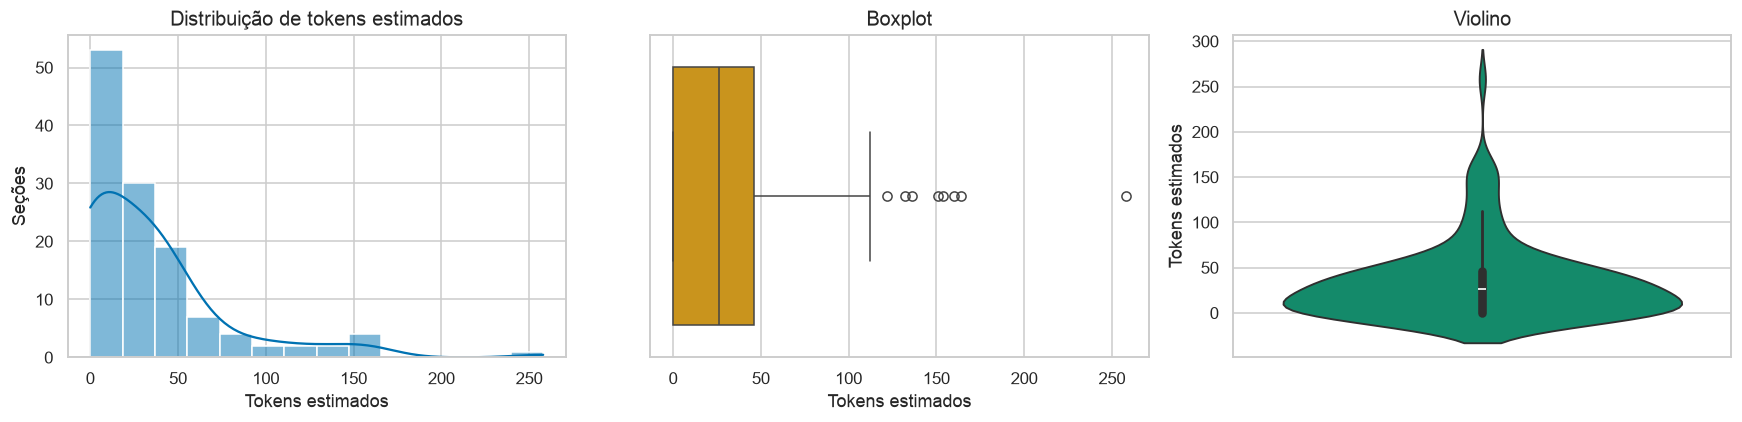

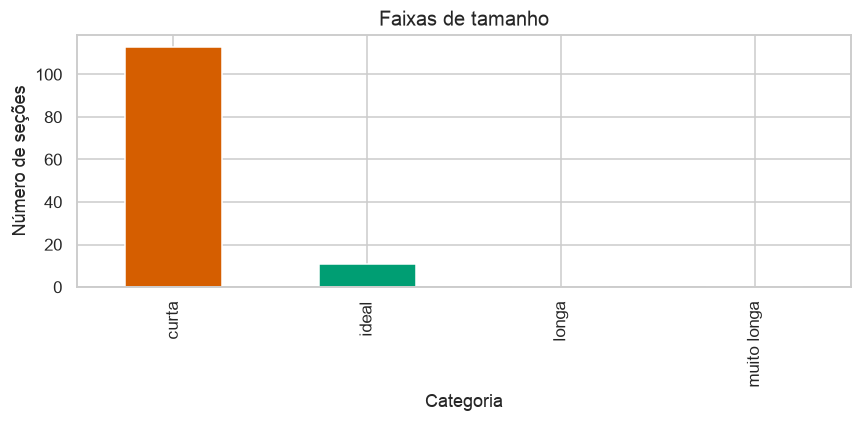

In [8]:
numericas = ['n_palavras','n_tokens_est','palavras_por_frase','comprimento_medio_palavra','densidade_numerica']
resumo = limpo[numericas].describe().T
resumo['mediana'] = limpo[numericas].median(); resumo['moda'] = limpo[numericas].mode().iloc[0]; resumo['assimetria'] = limpo[numericas].skew(); resumo['curtose'] = limpo[numericas].kurtosis()
display(resumo)
fig, axes = plt.subplots(1,3,figsize=(16,4))
sns.histplot(limpo.n_tokens_est, kde=True, ax=axes[0], color='#0072B2'); axes[0].set(title='Distribuição de tokens estimados',xlabel='Tokens estimados',ylabel='Seções')
sns.boxplot(x=limpo.n_tokens_est, ax=axes[1], color='#E69F00'); axes[1].set(title='Boxplot',xlabel='Tokens estimados')
sns.violinplot(y=limpo.n_tokens_est, ax=axes[2], color='#009E73'); axes[2].set(title='Violino',ylabel='Tokens estimados')
plt.tight_layout(); plt.savefig(FIG/'01_distribuicao_tamanho.png',dpi=150); plt.show()
fig, ax = plt.subplots(figsize=(8,4)); limpo['tamanho'].value_counts().reindex(['curta','ideal','longa','muito longa']).fillna(0).plot.bar(ax=ax,color=['#D55E00','#009E73','#0072B2','#CC79A7']); ax.set(title='Faixas de tamanho',xlabel='Categoria',ylabel='Número de seções'); plt.tight_layout(); plt.savefig(FIG/'02_faixas_tamanho.png',dpi=150); plt.show()

## Interpretação e decisão para o chatbot
Use a tabela para identificar a cauda longa e os gráficos para dimensionar chunks. Seções muito diferentes não devem receber o mesmo tratamento: blocos curtos podem ser anexados ao serviço-pai e blocos longos devem ser subdivididos por subtítulo/lista.

In [9]:
def tokens_filtrados(texto):
    palavras = re.findall(r'[A-Za-zÀ-ÿ]{3,}', texto.lower())
    return [p for p in palavras if norm(p) not in {norm(x) for x in STOPWORDS}]
todos = [p for texto in limpo.texto for p in tokens_filtrados(texto)]
freq = pd.Series(todos).value_counts()
print('vocabulário:', len(freq), '| termos que aparecem uma vez:', int((freq==1).sum()), '| riqueza lexical:', round(len(freq)/max(1,len(todos)),3))
display(freq.head(15).to_frame('frequencia'))
for n, nome in [(2,'bigramas'),(3,'trigramas')]:
    vec=CountVectorizer(ngram_range=(n,n), tokenizer=lambda x:x, preprocessor=lambda x:x, token_pattern=None)
    X=vec.fit_transform([tokens_filtrados(t) for t in limpo.texto])
    cont=np.asarray(X.sum(axis=0)).ravel(); termos=pd.Series(cont,index=vec.get_feature_names_out()).sort_values(ascending=False).head(10)
    print(nome); display(termos.to_frame('frequencia'))
display(pd.Series([s for lista in limpo.siglas for s in lista]).value_counts().head(15).to_frame('frequencia'))

vocabulário: 791 | termos que aparecem uma vez: 464 | riqueza lexical: 0.422


,frequencia
aqui,52
saúde,41
clique,41
sus,30
cartão,28
atendimento,20
hospital,20
protocolo,17
são,16
caps,15


bigramas


,frequencia
clique aqui,36
cartão sus,15
nacional sus,13
cartão nacional,13
sus cartão,13
distrito federal,12
hospital regional,10
cpf cartão,10
saber clique,7
clicando aqui,6


trigramas


,frequencia
cartão nacional sus,13
nacional sus cartão,13
sus cartão sus,13
cpf cartão nacional,10
saber clique aqui,5
sofrimento mental grave,5
clique aqui centro,5
clique aqui vigilância,5
governo distrito federal,4
qualquer pessoa pode,4


,frequencia
SUS,14
CPF,12
DF,11
UBS,11
CAPS,6
CODE,5
QR,5
SES,3
SEI-GDF,3
II,3


## Interpretação
Unigramas e n-gramas ajudam a formar consultas de teste e um glossário de siglas. Termos muito raros podem ser nomes de unidades ou erros de extração; não devem ser removidos automaticamente porque podem ser essenciais para uma pergunta específica.

# 8. Análise bivariada [INTERMEDIÁRIO]
Agora relacionamos tamanho, página, tipo e presença de informação prática. Correlação de Spearman é usada como pista monotônica e não como relação causal.

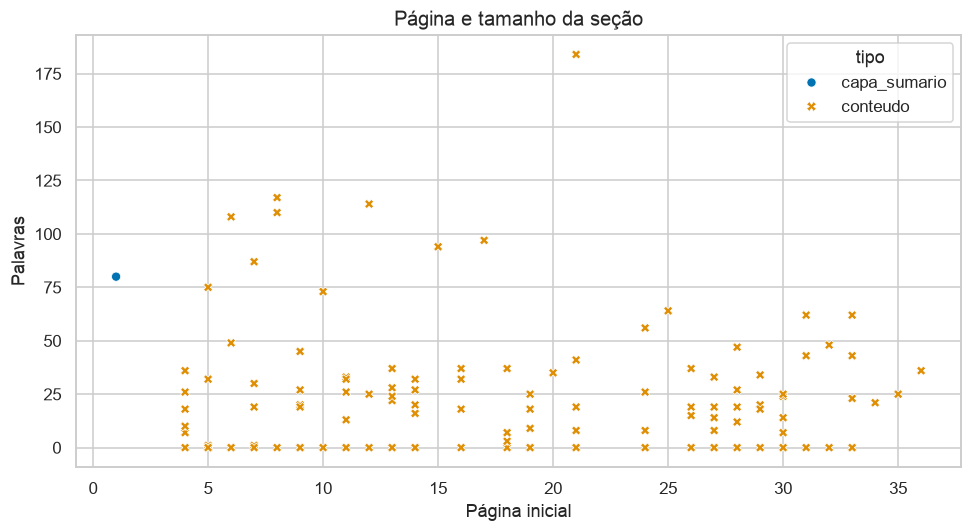

,tem_telefone,tem_horario,tem_link,tem_email,tem_endereco
tamanho,,,,,
curta,0.044,0.071,0.053,0.0,0.027
ideal,0.182,0.182,0.364,0.0,0.091


,n_palavras,n_tokens_est,palavras_por_frase,comprimento_medio_palavra,densidade_numerica
n_palavras,1.000000,1.000000,0.427865,0.728213,0.311017
n_tokens_est,1.000000,1.000000,0.427865,0.728213,0.311017
palavras_por_frase,0.427865,0.427865,1.000000,0.146093,-0.041734
comprimento_medio_palavra,0.728213,0.728213,0.146093,1.000000,0.114620
densidade_numerica,0.311017,0.311017,-0.041734,0.114620,1.000000


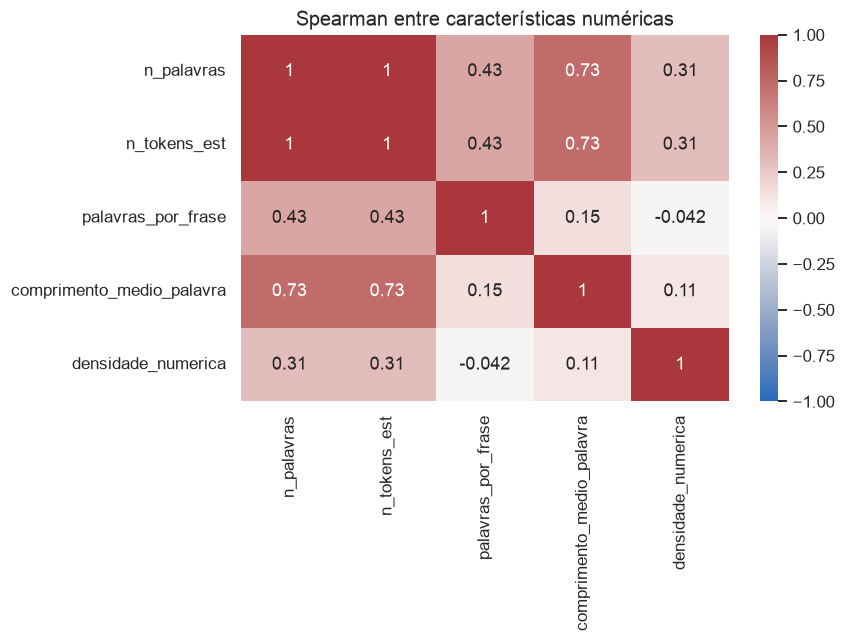

Mann-Whitney é apenas apoio exploratório: MannwhitneyuResult(statistic=np.float64(8.0), pvalue=np.float64(0.13244458393749906))


In [10]:
fig, ax=plt.subplots(figsize=(9,5)); sns.scatterplot(data=limpo,x='pagina',y='n_palavras',hue='tipo',style='tipo',palette='colorblind',ax=ax); ax.set(title='Página e tamanho da seção',xlabel='Página inicial',ylabel='Palavras'); plt.tight_layout(); plt.savefig(FIG/'03_pagina_tamanho.png',dpi=150); plt.show()
presencas=['tem_telefone','tem_horario','tem_link','tem_email','tem_endereco']
relacao=limpo.groupby('tamanho')[presencas].mean().round(3); display(relacao)
corr=limpo[numericas].corr(method='spearman'); display(corr)
plt.figure(figsize=(8,6)); sns.heatmap(corr,annot=True,cmap='vlag',vmin=-1,vmax=1); plt.title('Spearman entre características numéricas'); plt.tight_layout(); plt.savefig(FIG/'04_correlacao_spearman.png',dpi=150); plt.show()
if limpo.loc[limpo.tipo=='conteudo','n_tokens_est'].nunique()>1:
    a=limpo.loc[limpo.tipo=='conteudo','n_tokens_est']; b=limpo.loc[limpo.tipo=='capa_sumario','n_tokens_est']
    if len(b)>0: print('Mann-Whitney é apenas apoio exploratório:', mannwhitneyu(a,b,alternative='two-sided'))

## Interpretação
Relações observadas entre página, tamanho e sinais práticos servem para orientar auditoria: uma seção grande com vários telefones pode ser uma tabela legítima, enquanto um bloco grande de QR code pode indicar desorganização da extração. Com documento único e amostra pequena, não generalize os coeficientes.

# 9. Análise multivariada [AVANÇADO]
TF-IDF representa cada seção por termos. Em seguida calculamos proximidade, visualização 2D, clustering e tópicos. Tudo aqui é exploratório: não substitui leitura do PDF nem avaliação com perguntas reais.

,similaridade,secao_a,secao_b
0,1.000000,DOCUMENTOS NECESSÁRIOS,DOCUMENTOS NECESSÁRIOS
1,1.000000,DOCUMENTOS NECESSÁRIOS,DOCUMENTOS NECESSÁRIOS
2,1.000000,DOCUMENTOS NECESSÁRIOS,DOCUMENTOS NECESSÁRIOS
3,0.897962,ACESSO,ACESSO
4,0.823215,DOCUMENTOS NECESSÁRIOS,DOCUMENTOS NECESSÁRIOS
5,0.823215,DOCUMENTOS NECESSÁRIOS,DOCUMENTOS NECESSÁRIOS
6,0.823215,DOCUMENTOS NECESSÁRIOS,DOCUMENTOS NECESSÁRIOS
7,0.819042,ACESSO,DOCUMENTOS NECESSÁRIOS
8,0.798040,DOCUMENTOS NECESSÁRIOS,DOCUMENTOS NECESSÁRIOS
9,0.798040,DOCUMENTOS NECESSÁRIOS,DOCUMENTOS NECESSÁRIOS


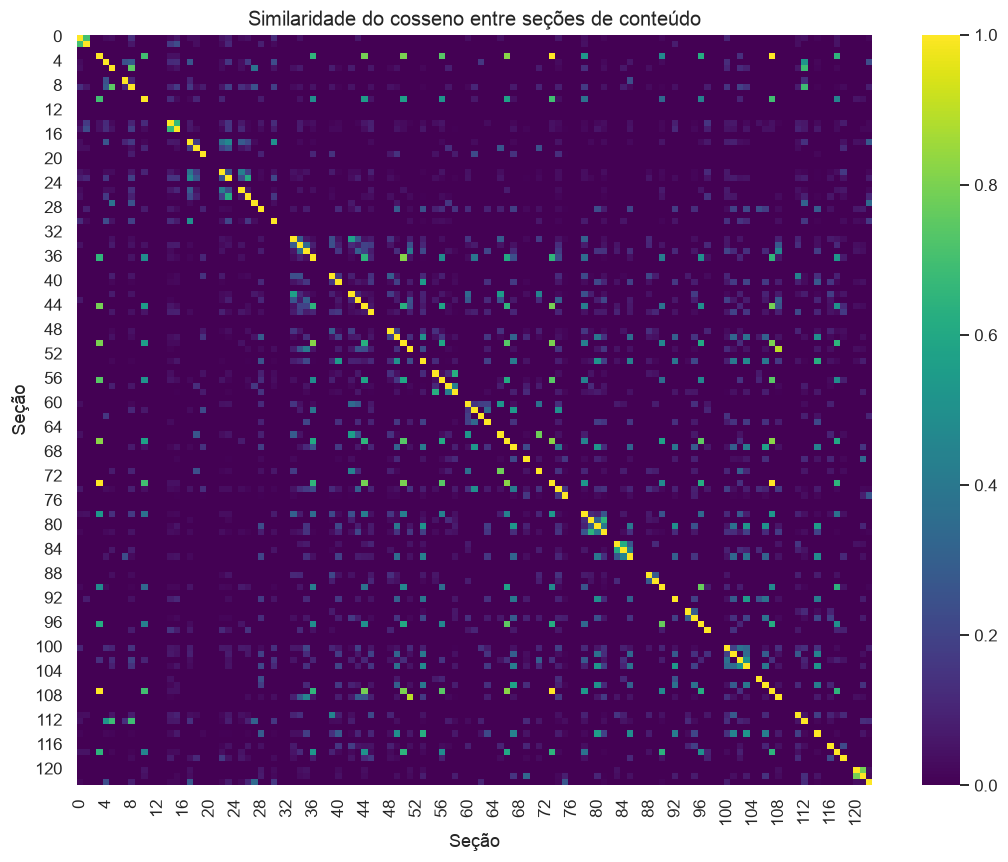

clustering exploratório: silhouette e k= 0.2347557334371167 5
cluster 0 ['saúde', 'aqui', 'atendimento', 'df', 'ubs', 'são', 'protocolo', 'clicando aqui']
cluster 1 ['sus', 'cartão', 'cartão sus', 'nacional', 'sus cartão', 'cartão nacional', 'nacional sus', 'cpf cartão']
cluster 2 ['às', 'governo distrito', 'site www', 'www participa', 'governo', 'participa', 'participa df', 'site']
cluster 3 ['clique aqui', 'clique', 'aqui', 'saber', 'saber clique', 'aqui saber', 'farmácias', 'saiba']
cluster 4 ['professoruesleipaterno wordpress', '27', '2021 10', '2021', 'alfabeto manual', 'wordpress', 'wordpress 2021', 'referência https']
Tópicos NMF exploratórios:
0 ['sus', 'cartão', 'cartão sus', 'sus cartão', 'nacional sus', 'nacional', 'cartão nacional', 'cpf cartão']
1 ['aqui', 'clique aqui', 'clique', 'saber', 'saber clique', 'farmácias', 'aqui saber', 'referência']
2 ['df', 'saúde', 'atendimento', 'às', 'protocolo', 'federal', 'distrito', 'distrito federal']


In [11]:
conteudo=limpo[limpo.tipo=='conteudo'].copy().reset_index(drop=True)
if len(conteudo)>=2:
    min_df = 1 if len(conteudo)<20 else 2
    vector=TfidfVectorizer(stop_words=list(STOPWORDS),min_df=min_df,ngram_range=(1,2))
    X=vector.fit_transform(conteudo.texto)
    sim=cosine_similarity(X)
    pares=[]
    for i in range(len(conteudo)):
        for j in range(i+1,len(conteudo)):
            pares.append((sim[i,j],conteudo.loc[i,'titulo'],conteudo.loc[j,'titulo']))
    pares_df=pd.DataFrame(sorted(pares,reverse=True)[:10],columns=['similaridade','secao_a','secao_b']); display(pares_df)
    plt.figure(figsize=(10,8)); sns.heatmap(sim,cmap='viridis'); plt.title('Similaridade do cosseno entre seções de conteúdo'); plt.xlabel('Seção'); plt.ylabel('Seção'); plt.tight_layout(); plt.savefig(FIG/'05_similaridade_cosseno.png',dpi=150); plt.show()
    n_comp=max(1,min(2,X.shape[1],X.shape[0]-1)); svd=TruncatedSVD(n_components=n_comp,random_state=42); coords=svd.fit_transform(X)
    if n_comp==1: coords=np.c_[coords,np.zeros(len(coords))]
    fig=px.scatter(x=coords[:,0],y=coords[:,1],color=conteudo.tamanho,hover_name=conteudo.titulo,title='Projeção 2D TF-IDF (exploratória)',labels={'x':'Componente 1','y':'Componente 2','color':'Tamanho'}); fig.write_html(FIG/'06_projecao_tfidf.html'); fig.show()
    melhor=None
    for k in range(2,min(6,len(conteudo)-1)+1):
        labels=KMeans(n_clusters=k,random_state=42,n_init=10).fit_predict(X); score=silhouette_score(X,labels)
        if melhor is None or score>melhor[0]: melhor=(score,k,labels)
    print('clustering exploratório: silhouette e k=', melhor[0], melhor[1])
    conteudo['cluster']=melhor[2]
    termos=np.array(vector.get_feature_names_out())
    for c in sorted(conteudo.cluster.unique()):
        mask=np.asarray(conteudo.cluster==c); centroid=X[mask].mean(axis=0).A1; print('cluster',c, list(termos[centroid.argsort()[::-1][:8]]))
    if X.shape[0]>=4 and X.shape[1]>=2:
        nmf=NMF(n_components=min(3,X.shape[0]-1,X.shape[1]),random_state=42,max_iter=500); W=nmf.fit_transform(X); print('Tópicos NMF exploratórios:')
        for i, comp in enumerate(nmf.components_): print(i, list(termos[comp.argsort()[::-1][:8]]))
else: print('Corpus de conteúdo insuficiente para TF-IDF.')

## Interpretação e decisão para o chatbot
Pares muito semelhantes são candidatos a redundância ou confusão de recuperação, mas a semelhança também pode refletir o template repetido de documentos necessários e acesso. Mantenha `servico`, `pagina` e trecho como metadados para desambiguar.

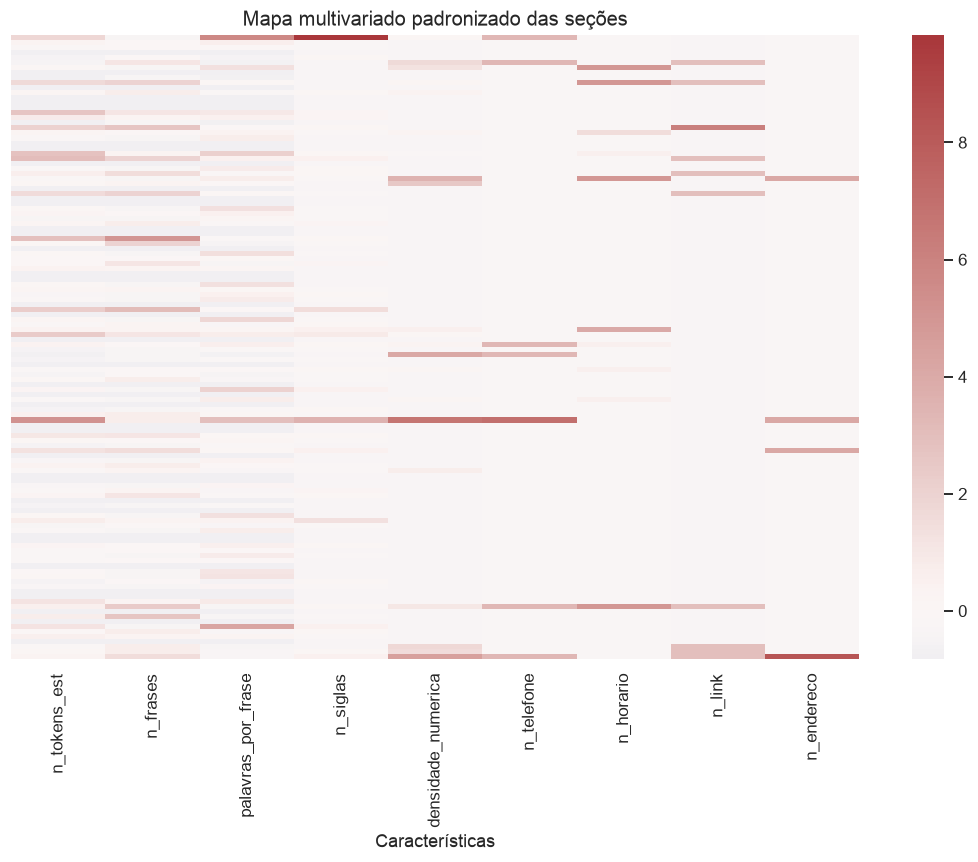

In [12]:
cols_heat=['n_tokens_est','n_frases','palavras_por_frase','n_siglas','densidade_numerica','n_telefone','n_horario','n_link','n_endereco']
mat=limpo[cols_heat].replace([np.inf,-np.inf],np.nan).fillna(0); mat=(mat-mat.mean())/mat.std(ddof=0).replace(0,1)
plt.figure(figsize=(10,8)); sns.heatmap(mat,cmap='vlag',center=0,yticklabels=False); plt.title('Mapa multivariado padronizado das seções'); plt.xlabel('Características'); plt.tight_layout(); plt.savefig(FIG/'07_mapa_multivariado.png',dpi=150); plt.show()

## Interpretação
O mapa permite localizar perfis atípicos combinando tamanho, siglas e informação prática. É uma visão de triagem; a classificação final depende do texto e do PDF original.

# 10. Outliers [INTERMEDIÁRIO]
Usamos IQR e z-score robusto baseado em mediana e MAD. Depois listamos os textos para leitura humana: uma lista de hospitais pode ser longa por motivo legítimo.

In [13]:
q1,q3=limpo.n_tokens_est.quantile([.25,.75]); iqr=q3-q1; lim_i=(q1-1.5*iqr,q3+1.5*iqr)
med=limpo.n_tokens_est.median(); mad=np.median(np.abs(limpo.n_tokens_est-med)); limpo['z_robusto']=0 if mad==0 else .6745*(limpo.n_tokens_est-med)/mad
out=limpo[(limpo.n_tokens_est<lim_i[0])|(limpo.n_tokens_est>lim_i[1])|(limpo.z_robusto.abs()>3.5)]
print('limites IQR:',lim_i,'| MAD:',mad,'| outliers sinalizados:',len(out))
display(out[['titulo','pagina','n_tokens_est','texto']].head(20))
print('Tratamento: longas legítimas -> subdividir; curtas/QR code -> validar; não remover automaticamente.')

limites IQR: (-69.0, 115.0) | MAD: 26.0 | outliers sinalizados: 8


,titulo,pagina,n_tokens_est,texto
15,ETAPAS,6,151,- Fazer o cadastro na plataforma Participa DF;...
18,DESCRIÇÃO,7,122,"O e-Protocolo é o Protocolo Eletrônico do GDF,..."
23,ETAPAS,8,154,"Após acessar o sistema, clicar em Novo Protoco..."
24,COMO ACOMPANHAR,8,164,"- Por meio do e-Protocolo, o cidadão poderá ac..."
40,SERVIÇOS,12,160,- Acolhimento à demanda espontânea. \n\n- Saúd...
54,MAIS SERVIÇOS DOS CENTROS DE REFERÊNCIA AQUI!,15,132,"Centro especializado em obesidade, diabetes e ..."
59,SERVIÇOS,17,136,CAPSi: atende crianças e adolescentes com sofr...
76,QR CODE,21,258,|HOSPITAL|TELEFONE|QR CODE||\n|---|---|---|---...


Tratamento: longas legítimas -> subdividir; curtas/QR code -> validar; não remover automaticamente.


## Interpretação
Outlier é um alerta de revisão, não um erro. Ações recomendadas: preservar listas factuais, dividir blocos longos em unidades recuperáveis e verificar títulos órfãos ou resíduos de imagem antes de excluir.

# 11. Cobertura de temas e requisitos [AVANÇADO]
A cobertura do sumário é medida por correspondência normalizada. Uma correspondência não garante qualidade: também observamos tamanho e informação prática.

,servico,encontrado,secoes,palavras,telefone,horario,endereco,link
0,Ouvidoria,True,6,341,True,True,False,True
1,LAI,True,4,98,True,False,False,False
2,e-Protocolo,True,7,425,True,True,False,True
3,UBS,True,17,656,True,False,True,True
4,Policlínicas,True,6,220,True,False,True,False
5,Centros Especializados,True,4,194,True,False,False,False
6,CAPS,True,9,491,True,True,True,False
7,Protocolo SES/DF,True,3,190,True,True,False,False
8,SISPE,True,3,270,True,False,False,True
9,SAMU,True,5,131,True,True,False,False


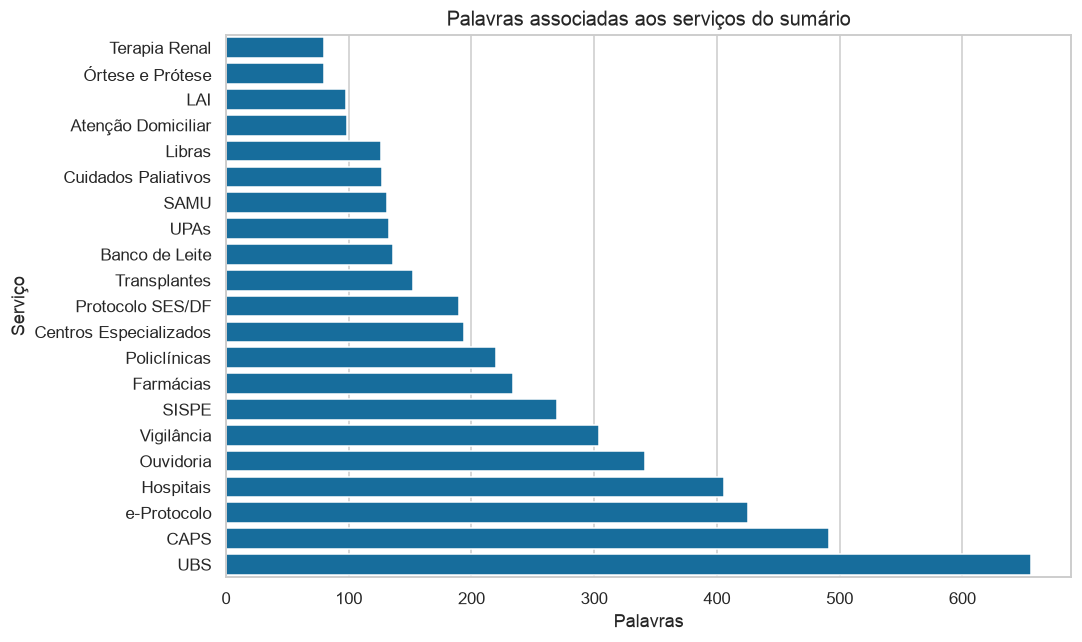

Serviços sem correspondência: []


In [14]:
palavras_servico={

}
# Âncoras compactas para evitar que pequenas diferenças de grafia escondam uma cobertura real.
ancoras={'Ouvidoria':['ouvidoria'],'LAI':['lei de acesso','lai'],'e-Protocolo':['e-protocolo'],'UBS':['unidade básica','ubs'],'Policlínicas':['policlínicas'],'Centros Especializados':['centros especializados'],'CAPS':['saúde mental','caps'],'Protocolo SES/DF':['protocolo da ses'],'SISPE':['sispe','peticionamento eletrônico'],'SAMU':['samu'],'UPAs':['pronto atendimento','upas'],'Hospitais':['hospitais'],'Farmácias':['farmácias'],'Banco de Leite':['banco de leite'],'Atenção Domiciliar':['atenção domiciliar'],'Cuidados Paliativos':['cuidados paliativos'],'Transplantes':['transplante'],'Terapia Renal':['terapia renal'],'Vigilância':['vigilância em saúde'],'Órtese e Prótese':['órtese e prótese'],'Libras':['libras']}
cob=[]
for serv, termos in ancoras.items():
    mask=limpo.titulo.map(norm).map(lambda x:any(norm(t) in x for t in termos)) | limpo.texto.map(norm).map(lambda x:any(norm(t) in x for t in termos))
    sub=limpo[mask]; cob.append({'servico':serv,'encontrado':bool(mask.any()),'secoes':int(mask.sum()),'palavras':int(sub.n_palavras.sum()),'telefone':bool(sub.tem_telefone.any()),'horario':bool(sub.tem_horario.any()),'endereco':bool(sub.tem_endereco.any()),'link':bool(sub.tem_link.any())})
cobertura=pd.DataFrame(cob); display(cobertura)
plt.figure(figsize=(10,6)); sns.barplot(data=cobertura.sort_values('palavras'),y='servico',x='palavras',hue='encontrado',legend=False,palette='colorblind'); plt.title('Palavras associadas aos serviços do sumário'); plt.xlabel('Palavras'); plt.ylabel('Serviço'); plt.tight_layout(); plt.savefig(FIG/'08_cobertura_servicos.png',dpi=150); plt.show()
print('Serviços sem correspondência:', cobertura.loc[~cobertura.encontrado,'servico'].tolist())

## Interpretação e decisão
Serviço encontrado não significa cobertura suficiente. Serviços com poucas palavras, sem informação prática ou dependentes de imagens/tabelas devem ser marcados como lacunas e complementados por fontes oficiais atualizadas.

In [15]:
req_path=BASE/'Documento_GRUPO10.txt'
reqs=[]
if req_path.exists():
    txt=req_path.read_text(encoding='utf-8')
    for codigo, desc in re.findall(r'\b(RF\d{2})\s*[—-]\s*([^\n]+)',txt): reqs.append((codigo,desc.strip()))
requisitos=pd.DataFrame(reqs,columns=['requisito','descricao'])
if requisitos.empty: requisitos=pd.DataFrame(columns=['requisito','descricao'])
requisitos['secao_cartilha']='' ; requisitos['cobertura']='nenhuma'; requisitos['observacao']='Preencher após validação do requisito contra trechos recuperados.'
display(requisitos if not requisitos.empty else pd.DataFrame(columns=['requisito','seção da cartilha que atende','cobertura','observação']))
print('A matriz é um ponto de partida: requisitos funcionais do chatbot não são automaticamente atendidos por uma cartilha de serviços.')

,requisito,descricao,secao_cartilha,cobertura,observacao
0,RF01,O sistema deverá permitir que o usuário envie ...,,nenhuma,Preencher após validação do requisito contra t...
1,RF02,O sistema deverá identificar informações relev...,,nenhuma,Preencher após validação do requisito contra t...
2,RF03,O sistema deverá utilizar as informações recup...,,nenhuma,Preencher após validação do requisito contra t...
3,RF04,O sistema deverá apresentar respostas relacion...,,nenhuma,Preencher após validação do requisito contra t...
4,RF05,O sistema deverá informar quando não houver in...,,nenhuma,Preencher após validação do requisito contra t...
5,RF06,O sistema deverá disponibilizar as fontes util...,,nenhuma,Preencher após validação do requisito contra t...
6,RF07,O sistema deverá permitir a consulta detalhada...,,nenhuma,Preencher após validação do requisito contra t...
7,RF08,O sistema deverá utilizar informações fornecid...,,nenhuma,Preencher após validação do requisito contra t...
8,RF09,O sistema deverá tratar perguntas fora do escopo.,,nenhuma,Preencher após validação do requisito contra t...
9,RF10,O sistema não deverá realizar diagnósticos ou ...,,nenhuma,Preencher após validação do requisito contra t...


A matriz é um ponto de partida: requisitos funcionais do chatbot não são automaticamente atendidos por uma cartilha de serviços.


## Interpretação
A cartilha é uma fonte de domínio, não uma especificação completa do chatbot. A matriz deve ser preenchida com evidência textual e classificada como total, parcial ou nenhuma; ausência de uma resposta na cartilha deve resultar em transparência, não em invenção.

# 12. Prontidão para RAG [AVANÇADO]
Simulamos blocos por palavras, usando a estimativa de 1,4 token por palavra. O cenário conta quantos chunks seriam gerados e quantas seções seriam cortadas. A implementação final deve trocar a estimativa pelo tokenizador do modelo escolhido.

,limite_tokens,sobreposicao,chunks,secoes_subdivididas,media_tokens_chunk
0,200,0.15,86,2,200
1,300,0.15,84,0,300
2,500,0.15,84,0,500


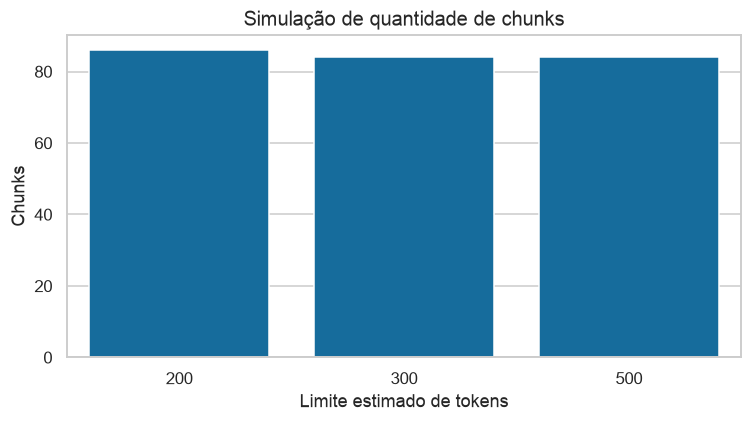

Recomendação: chunking hierárquico por serviço e subtítulo, com limite inicial intermediário e sobreposição moderada; validar com perguntas reais.


In [16]:
def simular_chunks(texto, limite_tokens, overlap=0.15):
    palavras=texto.split(); tamanho=max(1,int(limite_tokens/1.4)); passo=max(1,int(tamanho*(1-overlap)))
    if not palavras: return []
    return [' '.join(palavras[i:i+tamanho]) for i in range(0,len(palavras),passo)]
sim=[]
for limite in [200,300,500]:
    chunks=sum(len(simular_chunks(t,limite,.15)) for t in conteudo.texto)
    cortadas=sum(len(simular_chunks(t,limite,.15))>1 for t in conteudo.texto)
    sim.append({'limite_tokens':limite,'sobreposicao':0.15,'chunks':chunks,'secoes_subdivididas':cortadas,'media_tokens_chunk':limite})
sim_df=pd.DataFrame(sim); display(sim_df)
plt.figure(figsize=(7,4)); sns.barplot(data=sim_df,x='limite_tokens',y='chunks',color='#0072B2'); plt.title('Simulação de quantidade de chunks'); plt.xlabel('Limite estimado de tokens'); plt.ylabel('Chunks'); plt.tight_layout(); plt.savefig(FIG/'09_simulacao_chunks.png',dpi=150); plt.show()
print('Recomendação: chunking hierárquico por serviço e subtítulo, com limite inicial intermediário e sobreposição moderada; validar com perguntas reais.')

## Interpretação e decisão para o chatbot
A escolha final deve equilibrar contexto suficiente e precisão de recuperação. Recomenda-se preservar o título do serviço em todo chunk, subdividir listas longas por subtítulo e usar sobreposição moderada. A tabela calculada acima deve guiar a escolha, não uma regra fixa.

In [17]:
# Exportação: a versão alternativa por serviço recebe os metadados práticos calculados no corpus limpo.
alt_export=alt.copy()
alt_export['titulo_bruto']=alt_export['titulo']; alt_export['texto_bruto']=alt_export['texto']
alt_export['tipo']=np.where(alt_export.titulo.eq('Capa e sumário'),'capa_sumario','conteudo')
for col in ['tem_telefone','tem_horario','tem_link','tem_email','tem_endereco','n_telefone','n_horario','n_link','n_email','n_endereco','n_siglas','siglas','n_caracteres','n_frases','palavras_por_frase','comprimento_medio_palavra','n_tokens_est','densidade_numerica','tamanho']:
    alt_export[col]=alt_export.texto.map(lambda x: limpo.loc[limpo.texto.eq(x),col].iloc[0] if limpo.texto.eq(x).any() else (False if col.startswith('tem_') else 0))
alt_export['pagina']=alt_export['pagina'].astype(int)
ordem=['titulo','pagina','tipo','servico','texto','titulo_bruto','texto_bruto','n_palavras','n_tokens_est','n_caracteres','n_frases','palavras_por_frase','comprimento_medio_palavra','tem_telefone','n_telefone','tem_horario','n_horario','tem_link','n_link','tem_email','n_email','tem_endereco','n_endereco','n_siglas','siglas','densidade_numerica','tamanho']
alt_export['servico']=alt_export['titulo']; alt_export=alt_export[[c for c in ordem if c in alt_export]]
alt_export.to_csv(PROC/'cartilha_secoes_limpo.csv',index=False,encoding='utf-8')
alt_export.to_json(PROC/'cartilha_secoes_limpo.json',orient='records',force_ascii=False,indent=2)
alt_export.to_json(PROC/'cartilha_secoes_limpo.jsonl',orient='records',lines=True,force_ascii=False)
print('Exportados:', [p.name for p in PROC.iterdir()])
display(alt_export.head(3))

Exportados: ['cartilha_secoes_limpo.json', 'cartilha_secoes_limpo.jsonl', 'cartilha_secoes_limpo.csv']


,titulo,pagina,tipo,servico,texto,titulo_bruto,texto_bruto,n_palavras,n_tokens_est,n_caracteres,...,tem_link,n_link,tem_email,n_email,tem_endereco,n_endereco,n_siglas,siglas,densidade_numerica,tamanho
0,Capa e sumário,1,capa_sumario,Capa e sumário,Carta de Serviços Ao Cidadão **2026** \n\n\n\n...,Capa e sumário,Carta de Serviços Ao Cidadão **2026** \n\n\n\n...,176,0,0,...,False,0,False,0,False,0,0,0,0,0
1,Lei de Acesso à Informação (LAI),5,conteudo,Lei de Acesso à Informação (LAI),<!-- Start of picture text -->\nSite<br><!-- E...,Lei de Acesso à Informação (LAI),<!-- Start of picture text -->\nSite<br><!-- E...,366,0,0,...,False,0,False,0,False,0,0,0,0,0
2,Atendimento em Unidades de Pronto Atendimento ...,7,conteudo,Atendimento em Unidades de Pronto Atendimento ...,- **Virtual** : O e-Protocolo estará disponíve...,Atendimento em Unidades de Pronto Atendimento ...,- **Virtual** : O e-Protocolo estará disponíve...,686,0,0,...,False,0,False,0,False,0,0,0,0,0


## Interpretação do esquema de metadados
Cada registro exportado mantém `titulo`, `pagina`, `tipo`, `servico`, texto bruto e limpo, tamanho, sinais de informação prática, siglas e densidade numérica. Esse esquema permite filtrar fontes, exibir evidências e atualizar a base sem reconstruir toda a aplicação.

# 13. Conclusões e comunicação dos achados
## Resumo executivo
A cartilha é uma fonte relevante para serviços da SES-DF, mas não está pronta para indexação direta. A extração original fragmenta serviços em muitos subtítulos genéricos, cria vazios e pode desorganizar tabelas. A limpeza remove ruído de marcação sem alterar o conteúdo semântico. A preparação recomendada é agrupar por serviço, subdividir blocos longos por subtítulo, preservar página e evidência, e marcar informação prática por metadados. A cobertura deve ser validada contra o PDF e fontes oficiais atuais. Telefones, horários, links e endereços exigem revisão humana. A cartilha não cobre sozinha todos os requisitos do chatbot.

## Decisões para o chatbot
1. Preservar o CSV original para auditoria e usar a versão limpa por serviço para protótipo.
2. Não imputar texto; juntar títulos órfãos apenas com regra documentada.
3. Usar chunking hierárquico com título do serviço repetido e sobreposição moderada.
4. Indexar metadados de página, serviço, tipo, tamanho e informação prática.
5. Responder com trecho e fonte; declarar ausência de evidência.
6. Validar manualmente tabelas, QR codes, links, horários, telefones e possíveis dados pessoais.

## Lacunas, riscos e limitações
Amostra de um documento, estimativa de tokens, regexes aproximadas, conteúdo possivelmente perdido em tabelas/colunas, informação sujeita a desatualização e clusters/tópicos instáveis em corpus pequeno.

## Próximos passos
Validar a segmentação com o PDF; completar a matriz de requisitos; incorporar fontes oficiais de unidades e dados estruturados; gerar embeddings; indexar em banco vetorial; criar conjunto de perguntas reais; medir recuperação, fundamentação, transparência e falhas do RAG.